In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

# Resolve project root dynamically
import json
prediction_rows = []

PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

warnings.filterwarnings('ignore')

import importlib
import torch
import gpytorch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from src.data.data_loader import load_cmapss_data, StreamingCMAPSSDataset
import src.models.dkl_autoencoder_svgp as dkl_autoencoder_svgp
import src.models.train_dkl_svgp as train_dkl_svgp
importlib.reload(dkl_autoencoder_svgp)
importlib.reload(train_dkl_svgp)

from src.data.data_loader import load_cmapss_data, StreamingCMAPSSDataset
from src.models.train_dkl_svgp import train_dkl_autoencoder

from src.data.data_loader import load_cmapss_data
from src.models.train_svgp import train_svgp

In [ ]:
# 1. Define paths and features 
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'

# --- THE FIX: DROP CONSTANT SENSORS ---
# Rimuoviamo i sensori identificati nella EDA per sbloccare i gradienti del kernel
dead_sensors = ['s_1', 's_10', 's_18', 's_19']
features = [f's_{i}' for i in range(1, 22) if f's_{i}' not in dead_sensors]
num_features = len(features)
print(f"Using {num_features} informative features.")

# 2. Load Data
df_train = load_cmapss_data(str(DATA_DIR / 'train_FD001.txt'))
df_test = load_cmapss_data(str(DATA_DIR / 'test_FD001.txt'), str(DATA_DIR / 'RUL_FD001.txt'))

# Piecewise Linear RUL Clipping
MAX_RUL = 125
df_train['RUL'] = df_train['RUL'].clip(upper=MAX_RUL)
df_test['RUL'] = df_test['RUL'].clip(upper=MAX_RUL)

# 3. Strict Normalization for FEATURES (X)
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(df_train[features].values)

# 4. Strict Normalization for TARGET (y)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(df_train['RUL'].values.reshape(-1, 1)).flatten()

# 5. Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

# 6. Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

Using 17 informative features.


In [ ]:
# Execute the SVGP training loop
# We use 100 inducing points to compress the dataset representation
model, likelihood = train_svgp(
    train_loader=train_loader, 
    num_features=num_features, 
    num_inducing=256, 
    epochs=100, 
    lr=0.01
)

--- Starting SVGP Training (100 Epochs) ---
Epoch 01/100 - Loss (Negative Log Likelihood): 215.9981
Epoch 02/100 - Loss (Negative Log Likelihood): 180.6226
Epoch 03/100 - Loss (Negative Log Likelihood): 169.5324
Epoch 04/100 - Loss (Negative Log Likelihood): 164.2646
Epoch 05/100 - Loss (Negative Log Likelihood): 160.2799
Epoch 06/100 - Loss (Negative Log Likelihood): 157.6172
Epoch 07/100 - Loss (Negative Log Likelihood): 154.6530
Epoch 08/100 - Loss (Negative Log Likelihood): 152.9079
Epoch 09/100 - Loss (Negative Log Likelihood): 150.9178
Epoch 10/100 - Loss (Negative Log Likelihood): 149.6628
Epoch 11/100 - Loss (Negative Log Likelihood): 148.3455
Epoch 12/100 - Loss (Negative Log Likelihood): 146.3628
Epoch 13/100 - Loss (Negative Log Likelihood): 145.9005
Epoch 14/100 - Loss (Negative Log Likelihood): 145.0244
Epoch 15/100 - Loss (Negative Log Likelihood): 144.6098
Epoch 16/100 - Loss (Negative Log Likelihood): 144.1446
Epoch 17/100 - Loss (Negative Log Likelihood): 142.9068
Epoc

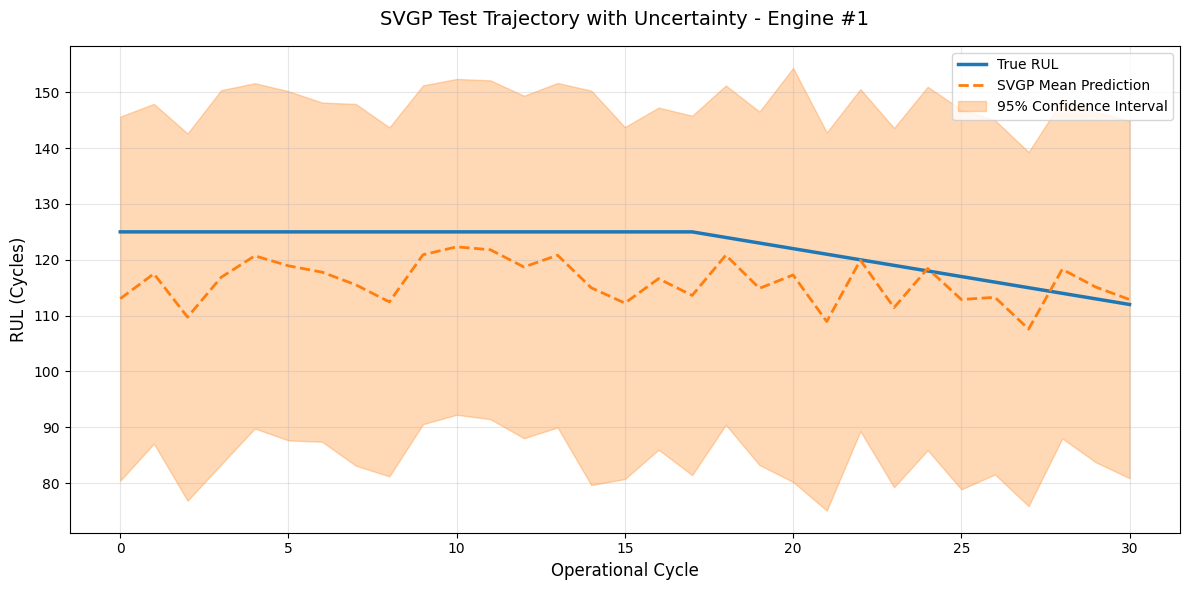

In [ ]:
def plot_svgp_predictions_corrected(engine_id=1):
    model.eval()
    likelihood.eval()

    # Extract test data
    engine_data = df_test[df_test['unit_nr'] == engine_id]
    
    # Scale X using the X scaler
    X_test_scaled = scaler_x.transform(engine_data[features].values)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_true = engine_data['RUL'].values

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        observed_pred = likelihood(model(X_test_tensor))
        
        # Extract mean and bounds in SCALED format
        mean_scaled = observed_pred.mean.numpy()
        lower_scaled, upper_scaled = observed_pred.confidence_region()
        lower_scaled = lower_scaled.numpy()
        upper_scaled = upper_scaled.numpy()

    # INVERSE TRANSFORM to get back to original RUL cycles
    mean = scaler_y.inverse_transform(mean_scaled.reshape(-1, 1)).flatten()
    lower = scaler_y.inverse_transform(lower_scaled.reshape(-1, 1)).flatten()
    upper = scaler_y.inverse_transform(upper_scaled.reshape(-1, 1)).flatten()

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label="True RUL", color='#1f77b4', linewidth=2.5)
    
    # SVGP Mean and Uncertainty Bands
    plt.plot(mean, label="SVGP Mean Prediction", color='#ff7f0e', linestyle='--', linewidth=2)
    plt.fill_between(range(len(mean)), lower, upper, alpha=0.3, color='#ff7f0e', label="95% Confidence Interval")

    plt.title(f"SVGP Test Trajectory with Uncertainty - Engine #{engine_id}", fontsize=14, pad=15)
    plt.xlabel("Operational Cycle", fontsize=12)
    plt.ylabel("RUL (Cycles)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_svgp_predictions_corrected(engine_id=1)

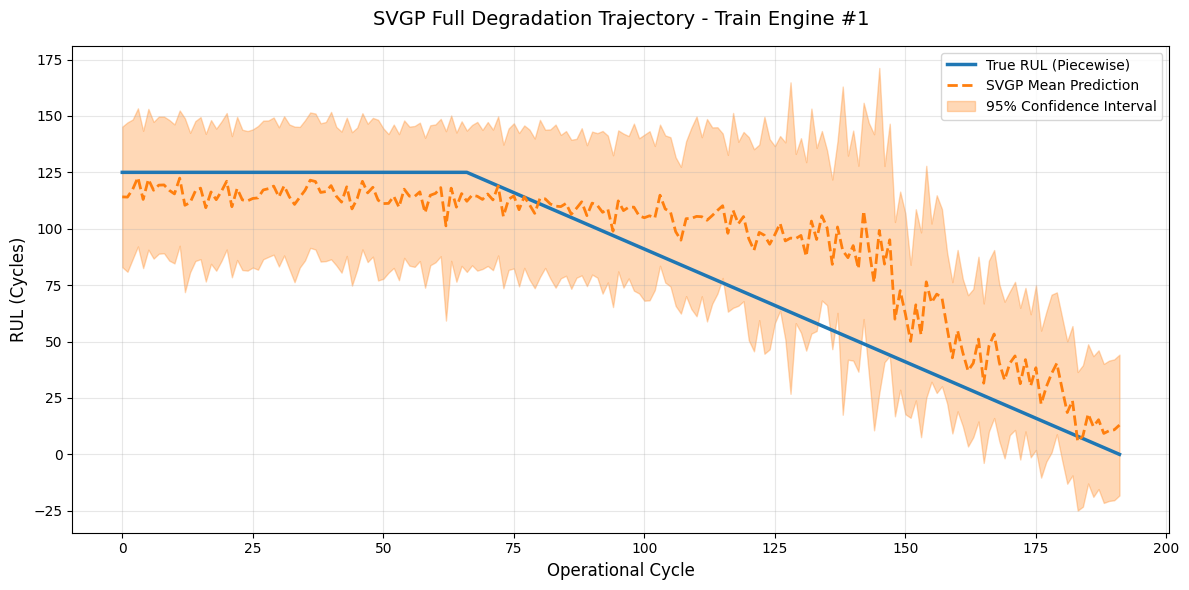

In [ ]:
def plot_svgp_full_degradation(engine_id=1):
    model.eval()
    likelihood.eval()

    # Engine data from TRAIN SET to see the full degradation trajectory
    engine_data = df_train[df_train['unit_nr'] == engine_id]
    
    # Scale X using the X scaler
    X_scaled = scaler_x.transform(engine_data[features].values)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    y_true = engine_data['RUL'].values

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        observed_pred = likelihood(model(X_tensor))
        
        # Extract mean and bounds in SCALED format
        mean_scaled = observed_pred.mean.numpy()
        lower_scaled, upper_scaled = observed_pred.confidence_region()
        
    # INVERSE TRANSFORM to get back to original RUL cycles
    mean = scaler_y.inverse_transform(mean_scaled.reshape(-1, 1)).flatten()
    lower = scaler_y.inverse_transform(lower_scaled.reshape(-1, 1)).flatten()
    upper = scaler_y.inverse_transform(upper_scaled.reshape(-1, 1)).flatten()

    # Plotting
    plt.figure(figsize=(12, 6))
    
    # True RUL (clipped at 125)
    plt.plot(y_true, label="True RUL (Piecewise)", color='#1f77b4', linewidth=2.5)
    
    # SVGP Prediction
    plt.plot(mean, label="SVGP Mean Prediction", color='#ff7f0e', linestyle='--', linewidth=2)
    plt.fill_between(range(len(mean)), lower, upper, alpha=0.3, color='#ff7f0e', label="95% Confidence Interval")

    plt.title(f"SVGP Full Degradation Trajectory - Train Engine #{engine_id}", fontsize=14, pad=15)
    plt.xlabel("Operational Cycle", fontsize=12)
    plt.ylabel("RUL (Cycles)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot on engine 1 to see the full degradation trajectory
plot_svgp_full_degradation(engine_id=1)

Starting Digital Twin Simulation...

Batch 0: Mean RUL = 120.2 cycles, Lower Bound = nan cycles
Batch 1: Mean RUL = 113.6 cycles, Lower Bound = nan cycles
Batch 2: Mean RUL = 113.4 cycles, Lower Bound = nan cycles
Batch 3: Mean RUL = 108.3 cycles, Lower Bound = nan cycles
Batch 4: Mean RUL = 96.7 cycles, Lower Bound = nan cycles
Batch 5: Mean RUL = 106.7 cycles, Lower Bound = nan cycles
Batch 6: Mean RUL = 99.0 cycles, Lower Bound = nan cycles
Batch 7: Mean RUL = 100.7 cycles, Lower Bound = nan cycles
Batch 8: Mean RUL = 102.1 cycles, Lower Bound = nan cycles
Batch 9: Mean RUL = 102.7 cycles, Lower Bound = nan cycles
Batch 10: Mean RUL = 81.3 cycles, Lower Bound = nan cycles
Batch 11: Mean RUL = 97.2 cycles, Lower Bound = nan cycles
Batch 12: Mean RUL = 87.5 cycles, Lower Bound = nan cycles
Batch 13: Mean RUL = 96.2 cycles, Lower Bound = nan cycles
Batch 14: Mean RUL = 102.3 cycles, Lower Bound = nan cycles
Batch 15: Mean RUL = 90.7 cycles, Lower Bound = nan cycles
Batch 16: Mean RUL =

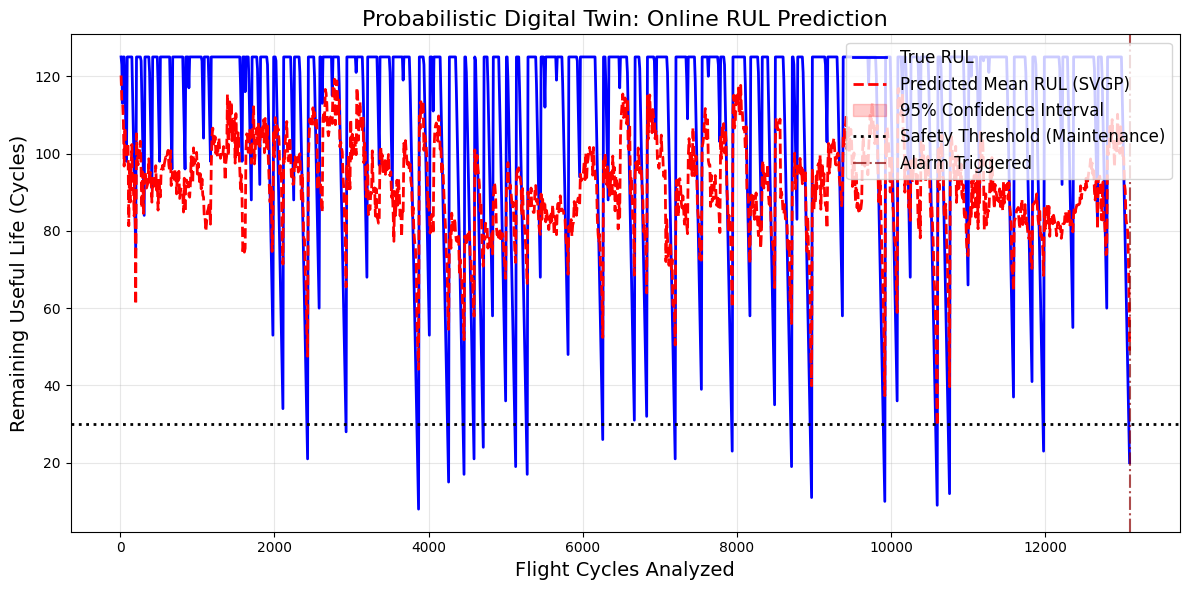

In [ ]:
# ==========================================
# 1. ONLINE UPDATING FUNCTION
# ==========================================
def update_model_online(model, likelihood, new_X, new_y, update_steps=3, lr=0.01):
    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.variational_parameters(), lr=lr)
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=len(new_y))
    
    for i in range(update_steps):
        optimizer.zero_grad()
        output = model(new_X)
        loss = -mll(output, new_y)
        loss.backward()
        optimizer.step()
        
    return model, likelihood

# ==========================================
# 2. PREPARE THE DATA STREAM
# ==========================================
X_test_scaled = scaler_x.transform(df_test[features].values)
y_test_scaled = scaler_y.transform(df_test['RUL'].values.reshape(-1, 1)).flatten()

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

# ==========================================
# 3. ONLINE UPDATING, CONSOLE LOGS & DATA COLLECTION
# ==========================================
threshold_RUL = 30  

# LISTS TO COLLECT DATA FOR VISUALIZATION
history_cycles = []
history_true_rul = []
history_mean_rul = []
history_lower_bound = []
history_upper_bound = []

print("Starting Digital Twin Simulation...\n")

model.eval()
likelihood.eval()

current_cycle = 0

for batch_idx, (stream_X, stream_y) in enumerate(test_loader):
    # Fine-tune the model
    model, likelihood = update_model_online(model, likelihood, stream_X, stream_y, update_steps=3)
    
    model.eval()
    likelihood.eval()
    
    with torch.no_grad():
        predictions = likelihood(model(stream_X))
        
        # Inverse transform
        mean_scaled = predictions.mean.numpy()
        lower_scaled, upper_scaled = predictions.confidence_region()
        
        mean_RUL = scaler_y.inverse_transform(mean_scaled.reshape(-1, 1)).flatten()
        lower_bound = scaler_y.inverse_transform(lower_scaled.numpy().reshape(-1, 1)).flatten()
        upper_bound = scaler_y.inverse_transform(upper_scaled.numpy().reshape(-1, 1)).flatten()
        true_RUL = scaler_y.inverse_transform(stream_y.numpy().reshape(-1, 1)).flatten()
        
        current_cycle += len(stream_y)
        
        # Check the latest reading in this 10-flight batch:
        current_lower_bound = lower_bound[-1]
        current_mean = mean_RUL[-1]
        
        # CONSOLE PRINT
        print(f"Batch {batch_idx}: Mean RUL = {current_mean:.1f} cycles, Lower Bound = {current_lower_bound:.1f} cycles")
        
        # Collect data for plotting
        history_cycles.append(current_cycle)
        history_true_rul.append(true_RUL[-1])
        history_mean_rul.append(current_mean)
        history_lower_bound.append(current_lower_bound)
        history_upper_bound.append(upper_bound[-1])
        
        # BUSINESS LOGIC & SAFETY STOP
        if current_lower_bound < threshold_RUL:
            print("\nALERT: Lower uncertainty bound dropped below the safety threshold!")
            print("Calling maintenance... Stopping machine simulation to prevent failure.\n")
            break 

# ==========================================
# 4. VISUALIZATION
# ==========================================
def plot_digital_twin(cycles, true_rul, mean_rul, lower_b, upper_b, threshold):
    plt.figure(figsize=(12, 6))
    
    # Plot the ground truth
    plt.plot(cycles, true_rul, label="True RUL", color="blue", linewidth=2)
    
    # Plot the SVGP predictions
    plt.plot(cycles, mean_rul, label="Predicted Mean RUL (SVGP)", color="red", linestyle="--", linewidth=2)
    
    # Plot the 95% Confidence Interval
    plt.fill_between(cycles, lower_b, upper_b, color="red", alpha=0.2, label="95% Confidence Interval")
    
    # Plot business safety threshold
    plt.axhline(y=threshold, color="black", linestyle=":", linewidth=2, label="Safety Threshold (Maintenance)")
    
    # Highlight the exact point where the alarm triggered
    plt.scatter(cycles[-1], lower_b[-1], color="darkred", s=100, zorder=5)
    plt.axvline(x=cycles[-1], color="darkred", linestyle="-.", alpha=0.7, label="Alarm Triggered")
    
    plt.title("Probabilistic Digital Twin: Online RUL Prediction", fontsize=16)
    plt.xlabel("Flight Cycles Analyzed", fontsize=14)
    plt.ylabel("Remaining Useful Life (Cycles)", fontsize=14)
    plt.legend(loc="upper right", fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_digital_twin(history_cycles, history_true_rul, history_mean_rul, history_lower_bound, history_upper_bound, threshold_RUL)

# DKL + SVGP

In [ ]:
import sys
import warnings
from pathlib import Path

# Resolve project root dynamically
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.data_loader import load_cmapss_data
from src.models.train_dkl_svgp import train_dkl_autoencoder




warnings.filterwarnings('ignore')

import torch
import gpytorch
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler

from src.data.data_loader import load_cmapss_data, StreamingCMAPSSDataset
from src.models.train_dkl_svgp import train_dkl_autoencoder

# ==========================================
# 1. PREPARAZIONE DATI E DATALOADER
# ==========================================
# Percorsi ai file raw 
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
TRAIN_FILE = str(DATA_DIR / 'train_FD001.txt')
TEST_FILE = str(DATA_DIR / 'test_FD001.txt')
RUL_FILE = str(DATA_DIR / 'RUL_FD001.txt')

# Sensori attivi (14 feature) usati per FD001 (scartati i costanti: 1, 5, 6, 10, 16, 18, 19)
ACTIVE_FEATURES = [
    's_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 
    's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21'
]
INPUT_DIM = len(ACTIVE_FEATURES)  # Dovrebbe essere 14
BATCH_SIZE = 256 # Dimensione del batch per il training

print("Caricamento e preprocessing dei dati...")
# Caricamento DataFrame con clipping RUL a 125

df_train = load_cmapss_data(TRAIN_FILE)
df_test = load_cmapss_data(TEST_FILE, RUL_FILE)

# Inizializza lo scaler
scaler = StandardScaler()

# Creazione Dataset (fit_scaler=True SOLO per il train set per evitare data leakage)
train_dataset = StreamingCMAPSSDataset(df_train, features=ACTIVE_FEATURES, scaler=scaler, fit_scaler=True)
test_dataset = StreamingCMAPSSDataset(df_test, features=ACTIVE_FEATURES, scaler=scaler, fit_scaler=False)

# Creazione DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dimensione Train: {len(train_dataset)} campioni | Dimensione Test: {len(test_dataset)} campioni")


# ==========================================
# 2. CONFIGURAZIONE E TRAINING DKL SVGP
# ==========================================
LATENT_DIM = 4   # Bottleneck dell'autoencoder
NUM_INDUCING = 100
EPOCHS = 20
LEARNING_RATE = 0.01
LAMBDA_RECON = 0.5  # Peso per bilanciare loss del GP e loss dell'Autoencoder

print("\nAvvio il training del DKL Autoencoder SVGP...")
model, likelihood = train_dkl_autoencoder(
    train_loader=train_loader,
    input_dim=INPUT_DIM,
    latent_dim=LATENT_DIM,
    num_inducing=NUM_INDUCING,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    lambda_recon=LAMBDA_RECON
)


# ==========================================
# 3. VALUTAZIONE POST-TRAINING (INFERENZA)
# ==========================================

print("\n--- Valutazione con ID Motore ---")
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
            prediction_rows = []
            # Iteriamo su tutto il test set 
            for test_x, test_y, unit_nrs in test_loader:
                
                # Predizione
                observed_pred = likelihood(model(test_x))
                pred_mean = observed_pred.mean
                lower, upper = observed_pred.confidence_region()
                
                # Stampa
                for i in range(len(test_x)):
                    u_id = unit_nrs[i].item()
                    y_true = test_y[i].item() if test_y.dim() == 1 else test_y[i][0].item()
                    y_pred = pred_mean[i].item()
                    y_lower = lower[i].item()
                    y_upper = upper[i].item()
                    
                    print(f"Motore: {u_id:03d} | Reale: {y_true:5.1f} | Predetto: {y_pred:5.1f} | "
                          f"Confidenza: [{y_lower:5.1f}, {y_upper:5.1f}]")
                    prediction_rows.append({
                        'unit_nr': int(u_id),
                        'true_rul': float(y_true),
                        'predicted_rul': float(y_pred),
                        'lower_rul': float(y_lower),
                        'upper_rul': float(y_upper)
                    })
            
            print(f"Motore: {u_id:03d} | Reale: {y_true:5.1f} | Predetto: {y_pred:5.1f} | "
                  f"Confidenza: [{lower[i].item():5.1f}, {upper[i].item():5.1f}]")
        

Caricamento e preprocessing dei dati...
Dimensione Train: 20631 campioni | Dimensione Test: 13096 campioni

Avvio il training del DKL Autoencoder SVGP...
--- Starting DKL Autoencoder SVGP Training (20 Epochs) ---
Epoch 01 | MLL Loss: 334304.6173 | Recon Loss: 0.5913
Epoch 02 | MLL Loss: 60620.8180 | Recon Loss: 0.3423
Epoch 03 | MLL Loss: 36044.4703 | Recon Loss: 0.3260
Epoch 04 | MLL Loss: 24755.0806 | Recon Loss: 0.3207
Epoch 05 | MLL Loss: 18571.0188 | Recon Loss: 0.3172
Epoch 06 | MLL Loss: 14748.0759 | Recon Loss: 0.3150
Epoch 07 | MLL Loss: 12148.3553 | Recon Loss: 0.3146
Epoch 08 | MLL Loss: 10383.2243 | Recon Loss: 0.3149
Epoch 09 | MLL Loss: 8961.4917 | Recon Loss: 0.3121
Epoch 10 | MLL Loss: 7967.4764 | Recon Loss: 0.3106
Epoch 11 | MLL Loss: 7144.5522 | Recon Loss: 0.3108
Epoch 12 | MLL Loss: 6475.6795 | Recon Loss: 0.3115
Epoch 13 | MLL Loss: 5906.2596 | Recon Loss: 0.3094
Epoch 14 | MLL Loss: 5412.8791 | Recon Loss: 0.3110
Epoch 15 | MLL Loss: 5040.9584 | Recon Loss: 0.310